
# Autocorrelação e Incertezas Estatísticas

Material de apoio ao TCC: Comparação e Otimização de Algoritmos de Monte
Carlo Aplicados ao Modelo de Ising (Diego R. Oliveira, UFPR).

Este notebook não roda nenhuma simulação nova. Ele carrega as séries
temporais de energia e magnetização já salvas pelos três notebooks de
simulação e calcula, para cada combinação de algoritmo, tamanho de rede e
temperatura, o tempo de autocorrelação integrado, seguindo o método
descrito na Seção 4.7 do TCC.

O tempo de autocorrelação integrado mede quantos passos, em média, uma
cadeia de Markov precisa para gerar uma configuração efetivamente
descorrelacionada da anterior. Ele é o ingrediente que faltava nos
notebooks anteriores para calcular a incerteza estatística correta das
médias físicas, no lugar da fórmula ingênua que assume amostras
independentes.


In [1]:

import os
from google.colab import drive

drive.mount('/content/drive')

assert os.path.ismount('/content/drive'), (
    "ERRO. Google Drive nao esta montado. "
    "Nao prossiga ate resolver isso."
)
print("Drive confirmado como montado corretamente.")


Mounted at /content/drive
Drive confirmado como montado corretamente.


In [2]:

!git clone https://github.com/diegorafael1010/ising-monte-carlo.git


Cloning into 'ising-monte-carlo'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 38 (delta 17), reused 21 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 60.73 KiB | 1.60 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [3]:

import glob
import re

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/content/ising-monte-carlo')
from ising_utils import temperatura_critica_onsager

PASTA_DADOS = '/content/drive/MyDrive/0_TCC_Diego/dados'


## Cálculo do tempo de autocorrelação via FFT

A função abaixo implementa exatamente o procedimento das Equações 4.40 a
4.44 do TCC. O sinal é centralizado, estendido com zeros para evitar
efeitos de contorno periódico artificial, transformado por FFT, elevado
ao quadrado no domínio da frequência (o que corresponde à autocovariância
no domínio do tempo, pelo teorema de Wiener-Khinchin), e trazido de volta
por FFT inversa. O termo de correção no final compensa a redução do
número de pares sobrepostos conforme o atraso temporal cresce.

Falta uma decisão prática que as equações do TCC não especificam sozinhas:
até onde somar a série de autocorrelações na Equação 4.37. A soma teórica
vai até o infinito, mas na prática precisa parar em algum ponto, porque
para atrasos grandes a autocorrelação medida vira ruído estatístico em
vez de sinal real. Então, adotamos aqui o critério de janela automática proposto por Sokal, que soma a série até um ponto W tal que W seja pelo menos c vezes o próprio tau estimado até ali, com c igual a cinco. A ideia é
parar de somar assim que a janela usada for grande o suficiente para
conter, com folga, a escala de tempo que estamos tentando medir.

In [4]:

def tau_integrado(serie: np.ndarray, c: int = 5, tau_max: int = None) -> tuple:
    '''Calcula o tempo de autocorrelacao integrado de uma serie temporal
    usando FFT (Equacoes 4.37 e 4.40 a 4.44 do TCC), com janela automatica
    de Sokal para decidir onde parar a soma.

    Paramtros
    ----------
    serie
        Serie temporal medida (energia ou magnetizacao, por exemplo).
    c
        Fator da janela automatica de Sokal. Valores entre 4 e 8 sao
        comuns na literatura, cinco e um meio termo razoavel.
    tau_max
        Limite superior absoluto para a soma, evitando somar ate o final
        da serie caso a janela automatica nunca convirja. Se nao for
        informado, usa um terco do tamanho da serie.

    Returns
    -------
    tuple
        O tempo de autocorrelacao integrado estimado e a janela final
        usada na soma, util como diagnostico.
    '''
    M = len(serie)
    if tau_max is None:
        tau_max = M // 3

    centrado = serie - serie.mean()
    tamanho_fft = 2 * M
    transformada = np.fft.fft(centrado, n=tamanho_fft)
    espectro = transformada * np.conj(transformada)
    autocovariancia = np.fft.ifft(espectro).real[:M]

    correcao_vies = M / (M - np.arange(M))
    autocovariancia = autocovariancia * correcao_vies
    rho = autocovariancia / autocovariancia[0]

    tau = 0.5
    for t in range(1, tau_max):
        tau += rho[t]
        if t >= c * tau:
            return tau, t
    return tau, tau_max



## Verificação da função contra um caso com resposta conhecida

Antes de aplicar a função aos dados reais, vale confirmar que ela acerta
um caso onde a resposta certa pode ser calculada de forma independente.
Um processo autorregressivo de primeira ordem, no qual cada ponto é uma
fração phi do ponto anterior mais ruído novo, tem correlação temporal
exatamente igual a phi elevado a t, e para esse caso o tempo de
autocorrelação integrado tem fórmula fechada, 0.5 mais phi dividido por
um menos phi.


In [5]:

def gerar_serie_ar1_teste(M, phi, rng):
    serie = np.zeros(M)
    for t in range(1, M):
        serie[t] = phi * serie[t-1] + rng.normal()
    return serie


rng_teste = np.random.default_rng(0)
phi_teste = 0.9
serie_teste = gerar_serie_ar1_teste(200000, phi_teste, rng_teste)

tau_teorico = 0.5 + phi_teste / (1 - phi_teste)
tau_medido, janela_usada = tau_integrado(serie_teste)

erro_relativo = abs(tau_medido - tau_teorico) / tau_teorico * 100

print(f"Tau teorico para phi igual a 0.9, {tau_teorico:.3f}")
print(f"Tau medido pela funcao FFT, {tau_medido:.3f} (janela usada, {janela_usada})")
print(f"Erro relativo, {erro_relativo:.2f} por cento")

assert erro_relativo < 5.0, "A funcao de autocorrelacao esta divergindo do valor teorico esperado"
print("OK. A funcao de autocorrelacao reproduz o caso teorico dentro da margem esperada.")


Tau teorico para phi igual a 0.9, 9.500
Tau medido pela funcao FFT, 9.586 (janela usada, 48)
Erro relativo, 0.90 por cento
OK. A funcao de autocorrelacao reproduz o caso teorico dentro da margem esperada.



## Carregando as séries e calculando tau para cada combinação

A função abaixo localiza o arquivo salvo de um algoritmo, tamanho de rede
e temperatura específicos, carrega as séries de energia e magnetização, e calcula o tau integrado de cada uma.

Para o Wolff, o tau calculado aqui está na unidade própria do algoritmo,
passos de Wolff, e não em MCS por sítio. A conversão para a escala comum
usa o tamanho médio do aglomerado de cada rodada, seguindo a Equação 4.47
do TCC. Para Metropolis e Swendsen-Wang, um passo já equivale a um MCS
por sítio, então essa conversão extra não é necessária, só multiplicar
pelo intervalo de amostragem usado na coleta.


In [7]:

def localizar_arquivo(algoritmo, L, T, pasta_dados):
    candidatos = glob.glob(f'{pasta_dados}/{algoritmo}_L{L}_T*.npz')
    for caminho in candidatos:
        m = re.search(rf'{algoritmo}_L{L}_T([\d.]+)\.npz$', caminho)
        if m and abs(float(m.group(1)) - T) < 1e-6:
            return caminho
    return None


def processar_combinacao(algoritmo, L, T, pasta_dados, intervalo_amostragem=10):
    caminho = localizar_arquivo(algoritmo, L, T, pasta_dados)
    if caminho is None:
        return None

    dados = np.load(caminho)
    energia = dados['energia']
    magnetizacao = dados['magnetizacao']

    tau_e_amostras, _ = tau_integrado(energia)
    tau_m_amostras, _ = tau_integrado(magnetizacao)

    if algoritmo == 'wolff':
        tamanho_medio_aglomerado = dados['tamanho_cluster'].mean()
        fator_conversao = tamanho_medio_aglomerado / (L * L)
        tau_e_mcs = tau_e_amostras * fator_conversao
        tau_m_mcs = tau_m_amostras * fator_conversao
    else:
        tau_e_mcs = tau_e_amostras * intervalo_amostragem
        tau_m_mcs = tau_m_amostras * intervalo_amostragem

    M = len(energia)
    e_erro_correto = np.sqrt((energia.var(ddof=1) / M) * 2 * tau_e_amostras)
    m_erro_correto = np.sqrt((magnetizacao.var(ddof=1) / M) * 2 * tau_m_amostras)

    return {
        'tau_e_amostras': tau_e_amostras, 'tau_m_amostras': tau_m_amostras,
        'tau_e_mcs': tau_e_mcs, 'tau_m_mcs': tau_m_mcs,
        'e_media': energia.mean(), 'e_erro_correto': e_erro_correto,
        'm_media': magnetizacao.mean(), 'm_erro_correto': m_erro_correto,
        'n_amostras': M,
    }


In [8]:

L_valores = [16, 32, 64, 128]
T_valores = [1.50, 2.00, 2.269, 2.50, 3.00]
algoritmos = ['metropolis', 'wolff', 'swendsen_wang']

resultados = {}
for algoritmo in algoritmos:
    for L in L_valores:
        for T in T_valores:
            r = processar_combinacao(algoritmo, L, T, PASTA_DADOS)
            if r is not None:
                resultados[(algoritmo, L, T)] = r

print(f"Combinacoes processadas, {len(resultados)} de {len(algoritmos) * len(L_valores) * len(T_valores)} esperadas")

faltando = []
for algoritmo in algoritmos:
    for L in L_valores:
        for T in T_valores:
            if (algoritmo, L, T) not in resultados:
                faltando.append((algoritmo, L, T))
if faltando:
    print("Faltando,", faltando)


Combinacoes processadas, 60 de 60 esperadas



## Salvando os resultados para uso posterior

Os valores de tau e do erro corrigido calculados aqui vão ser usados de
novo, tanto para atualizar a comparação de consistência entre algoritmos
quanto para a análise de desempenho computacional. Em vez de recalcular
tudo de novo em cada notebook futuro, salvamos um resumo compacto em um
único arquivo.


In [9]:

import json

resumo_serializavel = {
    f"{algoritmo}|{L}|{T}": {k: float(v) for k, v in dados.items()}
    for (algoritmo, L, T), dados in resultados.items()
}

caminho_resumo = f'{PASTA_DADOS}/resumo_autocorrelacao.json'
with open(caminho_resumo, 'w') as arquivo:
    json.dump(resumo_serializavel, arquivo, indent=2)

print(f"Resumo salvo em, {caminho_resumo}")
print(f"Total de combinacoes no resumo, {len(resumo_serializavel)}")


Resumo salvo em, /content/drive/MyDrive/0_TCC_Diego/dados/resumo_autocorrelacao.json
Total de combinacoes no resumo, 60



## O expoente crítico dinâmico medido

A Equação 4.45 do TCC estabelece que o tempo de autocorrelação perto da
temperatura crítica cresce como uma potência do tamanho da rede, com
expoente z próprio de cada algoritmo. O gráfico abaixo usa os quatro
tamanhos de rede simulados, na temperatura mais próxima de Tc, para
estimar esse expoente diretamente dos seus dados, por meio de um ajuste
linear em escala logarítmica. Os valores de referência da literatura, já
citados no Capítulo 3 do TCC, são próximos de 2.17 para o Metropolis e
próximos de 0.25 para os dois algoritmos de aglomerado.


Temperatura usada para o ajuste, 2.269


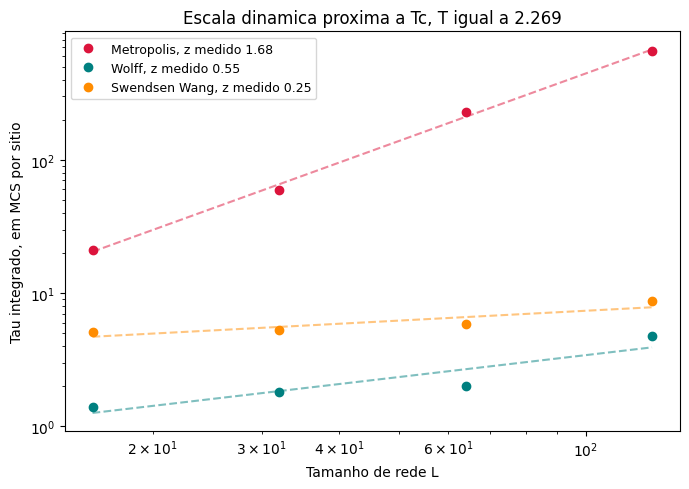

In [10]:

T_critica_usada = min(T_valores, key=lambda T: abs(T - temperatura_critica_onsager()))
print(f"Temperatura usada para o ajuste, {T_critica_usada}")

cores_algoritmo = {'metropolis': 'crimson', 'wolff': 'teal', 'swendsen_wang': 'darkorange'}
nomes_exibicao = {'metropolis': 'Metropolis', 'wolff': 'Wolff', 'swendsen_wang': 'Swendsen Wang'}

fig, ax = plt.subplots(figsize=(7, 5))

for algoritmo in algoritmos:
    Ls_disponiveis = sorted(L for (a, L, T) in resultados if a == algoritmo and T == T_critica_usada)
    taus = [resultados[(algoritmo, L, T_critica_usada)]['tau_e_mcs'] for L in Ls_disponiveis]

    if len(Ls_disponiveis) < 2:
        continue

    log_L = np.log(Ls_disponiveis)
    log_tau = np.log(taus)
    z_medido, intercepto = np.polyfit(log_L, log_tau, 1)

    cor = cores_algoritmo[algoritmo]
    ax.plot(Ls_disponiveis, taus, 'o', color=cor, label=f"{nomes_exibicao[algoritmo]}, z medido {z_medido:.2f}")

    L_fino = np.linspace(min(Ls_disponiveis), max(Ls_disponiveis), 50)
    ax.plot(L_fino, np.exp(intercepto) * L_fino ** z_medido, '--', color=cor, alpha=0.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Tamanho de rede L')
ax.set_ylabel('Tau integrado, em MCS por sitio')
ax.set_title(f'Escala dinamica proxima a Tc, T igual a {T_critica_usada}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{PASTA_DADOS}/expoente_dinamico_medido.png', dpi=150)
plt.show()
